## Exercise 00 : Line chart

In [1]:
import pandas as pd
import sqlite3

### Make a connection to the database

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query that gets datetime from pageviews table

In [3]:
query = "SELECT datetime FROM pageviews WHERE uid LIKE 'user_%'"
pgvws = pd.read_sql(sql=query, con=conn, parse_dates='datetime')

### Using Pandas, create new dataframe where visits are counted and grouped by date

In [4]:
df = pd.DataFrame({'date': pd.to_datetime(pgvws['datetime']).dt.date})
df = df.groupby('date').value_counts()
len(df)

33

### Create a graph

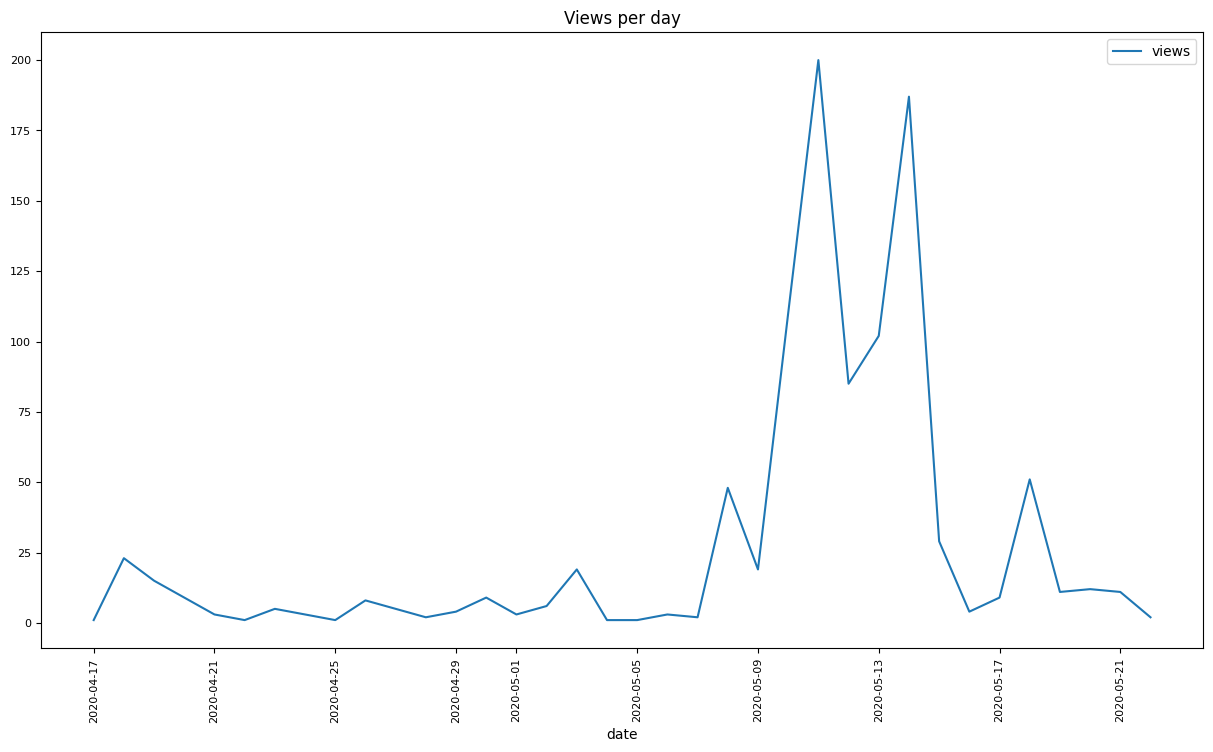

In [5]:
line_chart = df.plot(
    x='date', 
    y='count', 
    kind='line', 
    figsize=(15, 8), 
    fontsize=8, 
    title='Views per day', 
    rot=90, 
    grid=False, 
    legend=True,
    label='views')

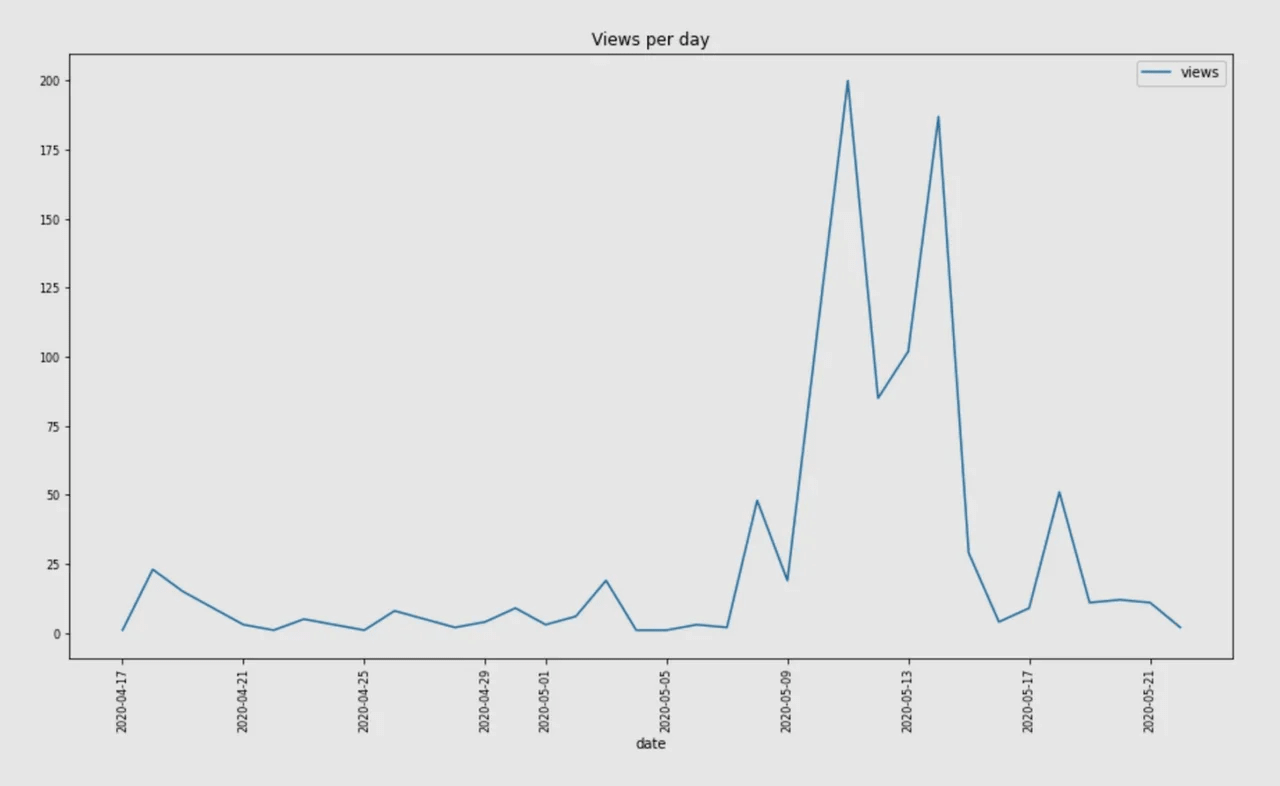

### Close the connection to the database

In [6]:
conn.close()